# Setup Imports

In [14]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_covtype

# Load dataset 

In [16]:
# The file yeast.csv was downloaded from https://www.kaggle.com/datasets/samanemami/yeastcsv?resource=download 

import pandas as pd

# Load the CSV file
df = pd.read_csv("yeast.csv")

# View first few rows
print(df.head())

# Check shape
print(df.shape)

    mcg   gvh   alm   mit  erl  pox   vac   nuc name
0  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22  MIT
1  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22  MIT
2  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22  MIT
3  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22  NUC
4  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22  MIT
(1484, 9)


# Data Preprocessing


In [17]:
# Check for missing values in each column
missing_counts = df.isna().sum()

print("Missing values per column:")
print(missing_counts)

print("\nAny missing values in dataset?:", df.isna().any().any())

Missing values per column:
mcg     0
gvh     0
alm     0
mit     0
erl     0
pox     0
vac     0
nuc     0
name    0
dtype: int64

Any missing values in dataset?: False


In [ ]:
# No missing values in yeast.cv but this is how we would remove them anyway
# Makes a copy of dataframe without rows containing NaN values
df_dropped = df.dropna().copy()

print("Original shape:", df.shape)
print("Shape after dropping missing rows:", df_dropped.shape)

Original shape: (1484, 9)
Shape after dropping missing rows: (1484, 9)


In [19]:

# Now we separate the features from the target and drop the protein name since it isn't used in the model
# Drop protein name column (first column)
X = df_dropped.iloc[:, 1:-1]   # features (8 numeric columns)
y = df_dropped.iloc[:, -1]     # target (localization class)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Feature shape: (1484, 7)
Target shape: (1484,)

Class distribution:
name
CYT    463
NUC    429
MIT    244
ME3    163
ME2     51
ME1     44
EXC     35
VAC     30
POX     20
ERL      5
Name: count, dtype: int64


In [20]:
# Now we set up our train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # important for multiclass balance
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1187, 7)
X_test shape: (297, 7)


# Random Forest Model

In [21]:
# Create a model to test

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# Predict on test set
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.5858585858585859

Classification Report:
              precision    recall  f1-score   support

         CYT       0.55      0.66      0.60        93
         ERL       0.00      0.00      0.00         1
         EXC       0.40      0.29      0.33         7
         ME1       0.50      0.56      0.53         9
         ME2       0.33      0.20      0.25        10
         ME3       0.72      0.81      0.76        32
         MIT       0.62      0.59      0.60        49
         NUC       0.59      0.56      0.57        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.59       297
   macro avg       0.47      0.39      0.41       297
weighted avg       0.57      0.59      0.57       297



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

## Overfitting, Underfitting, and Cross-Validation (Grid Search)

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best CV accuracy:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best CV accuracy: 0.6015175690529377
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [24]:
# Re-train Using the Best Parameters + Evaluate on Test Set

best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Test Accuracy (tuned):", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (tuned):")
print(classification_report(y_test, y_pred_best, zero_division=0))

Test Accuracy (tuned): 0.6060606060606061

Classification Report (tuned):
              precision    recall  f1-score   support

         CYT       0.54      0.67      0.60        93
         ERL       0.00      0.00      0.00         1
         EXC       0.50      0.43      0.46         7
         ME1       0.67      0.67      0.67         9
         ME2       0.40      0.20      0.27        10
         ME3       0.73      0.84      0.78        32
         MIT       0.67      0.57      0.62        49
         NUC       0.61      0.59      0.60        86
         POX       1.00      0.25      0.40         4
         VAC       0.00      0.00      0.00         6

    accuracy                           0.61       297
   macro avg       0.51      0.42      0.44       297
weighted avg       0.60      0.61      0.59       297



# Plot best RF Model

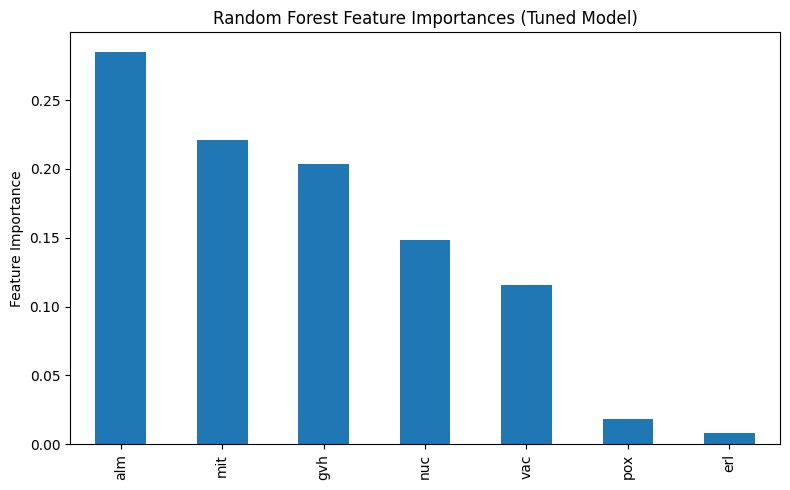

alm    0.284987
mit    0.221020
gvh    0.203307
nuc    0.148216
vac    0.115985
pox    0.018224
erl    0.008261
dtype: float64

In [25]:
# Get feature importances from tuned model
importances = best_rf.feature_importances_

# Match them to column names
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances (Tuned Model)")
plt.tight_layout()
plt.show()

feat_imp

# Analysis: 
Feature importance analysis shows that alm, mit, and gvh contribute most strongly to classification decisions, while pox and erl have minimal influence.